# Evaluate Pretrained DocAligner
This notebook evaluates the DocAligner model on the SmartDoc Challenge dataset step-by-step.

In [1]:
import os
import glob
import xml.etree.ElementTree as ET
import cv2
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# Patch for TurboJPEG on Windows
try:
    import turbojpeg
    class DummyTurboJPEG:
        def __init__(self, *args, **kwargs): pass
    turbojpeg.TurboJPEG = DummyTurboJPEG
except ImportError:
    pass

from docaligner import DocAligner

## Helper Functions
Parse the ground truth XML and extract frames from videos.

In [2]:
def parse_ground_truth(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    frames = {}
    seg_results = root.find('segmentation_results')
    if seg_results is None:
        return frames
        
    for frame in seg_results.findall('frame'):
        if frame.get('rejected') == 'true':
            continue
        index = int(frame.get('index'))
        points = {}
        for point in frame.findall('point'):
            name = point.get('name')
            x = float(point.get('x'))
            y = float(point.get('y'))
            points[name] = (x, y)
        if len(points) == 4 and all(k in points for k in ['tl', 'tr', 'br', 'bl']):
            frames[index] = points
    return frames

def extract_frames(video_path, frame_indices):
    cap = cv2.VideoCapture(video_path)
    extracted = {}
    for idx in sorted(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx - 1)
        ret, frame = cap.read()
        if ret:
            extracted[idx] = frame
    cap.release()
    return extracted

def compute_iou(pred_pts, gt_pts):
    p1 = Polygon(pred_pts)
    p2 = Polygon(gt_pts)
    if not p1.is_valid: p1 = p1.convex_hull
    if not p2.is_valid: p2 = p2.convex_hull
    try:
        return p1.intersection(p2).area / p1.union(p2).area
    except:
        return 0.0

## Model Initialization
Load the DocAligner model with the mobile-friendly FastViT backbone.

In [3]:
print("Initializing DocAligner...")
try:
    model = DocAligner(model_cfg='fastvit_sa24')
    print("Initialized DocAligner with fastvit_sa24 backbone")
except Exception as e:
    print(f"Failed to load fastvit_sa24: {e}. Trying lcnet...")
    try:
        model = DocAligner(model_cfg='lcnet')
        print("Initialized DocAligner with lcnet backbone")
    except:
        model = DocAligner()
        print("Initialized DocAligner with default backbone")

Initializing DocAligner...
Initialized DocAligner with fastvit_sa24 backbone


## Setup Paths

In [4]:
base_dir = r"data"
videos_dir = os.path.join(base_dir, "sampleDataset", "input_sample", "background00")
gt_dir = os.path.join(base_dir, "sampleDataset", "input_sample_groundtruth", "background00_gt")

videos = glob.glob(os.path.join(videos_dir, "*.avi"))
print(f"Found {len(videos)} videos.")

Found 3 videos.


## Evaluation Loop
Extract frames, perform inference, and calculate metrics.

In [5]:
all_results = []
sample_interval = 10

for video_path in videos:
    stem = os.path.splitext(os.path.basename(video_path))[0]
    gt_path = os.path.join(gt_dir, f"{stem}.gt.xml")
    
    if not os.path.exists(gt_path):
        print(f"Skipping {stem}, ground truth not found.")
        continue
        
    gt_data = parse_ground_truth(gt_path)
    if not gt_data:
        continue
        
    valid_indices = sorted(list(gt_data.keys()))
    sampled_indices = valid_indices[::sample_interval]
    
    print(f"Video {stem}: extracting {len(sampled_indices)} frames...")
    frames = extract_frames(video_path, sampled_indices)
    
    for idx, frame in frames.items():
        img_filename = f"{stem}_frame{idx}.jpg"
        
        pts = gt_data[idx]
        gt_array = np.array([pts['tl'], pts['tr'], pts['br'], pts['bl']], dtype=np.float32)
        
        try:
            preds = model(frame)
            if isinstance(preds, dict) and 'polygon' in preds:
                pred_array = np.array(preds['polygon'])
            else:
                pred_array = np.array(preds)
            
            if pred_array.shape != (4, 2):
                continue
            
            pixel_error = np.mean(np.linalg.norm(pred_array - gt_array, axis=1))
            iou = compute_iou(pred_array, gt_array)
            
            all_results.append({
                'filename': img_filename,
                'frame': frame,
                'gt': gt_array,
                'pred': pred_array,
                'error': float(pixel_error),
                'iou': float(iou)
            })
        except Exception as e:
            pass

print(f"Processed {len(all_results)} images successfully.")

Video datasheet001: extracting 22 frames...
Video letter001: extracting 18 frames...
Video magazine001: extracting 20 frames...
Processed 60 images successfully.


## Summary Report

In [6]:
all_results.sort(key=lambda x: x['error'], reverse=True)

print("="*50)
print("SUMMARY REPORT")
print("="*50)
print(f"Total images tested: {len(all_results)}")

avg_error = np.mean([r['error'] for r in all_results])
avg_iou = np.mean([r['iou'] for r in all_results])

print(f"Average pixel error: {avg_error:.2f} pixels")
print(f"Average IoU:         {avg_iou:.4f}")

iou_arr = np.array([r['iou'] for r in all_results])
good = np.sum(iou_arr > 0.9)
okay = np.sum((iou_arr > 0.7) & (iou_arr <= 0.9))
poor = np.sum(iou_arr <= 0.7)
total = len(all_results)

print(f"% IoU > 0.9 (good):      {good/total*100:.1f}%")
print(f"% IoU 0.7-0.9 (okay):    {okay/total*100:.1f}%")
print(f"% IoU < 0.7 (poor):      {poor/total*100:.1f}%")

SUMMARY REPORT
Total images tested: 60
Average pixel error: 7.66 pixels
Average IoU:         0.9625
% IoU > 0.9 (good):      100.0%
% IoU 0.7-0.9 (okay):    0.0%
% IoU < 0.7 (poor):      0.0%


## Visualization
Plot the worst and best performing predictions inline.

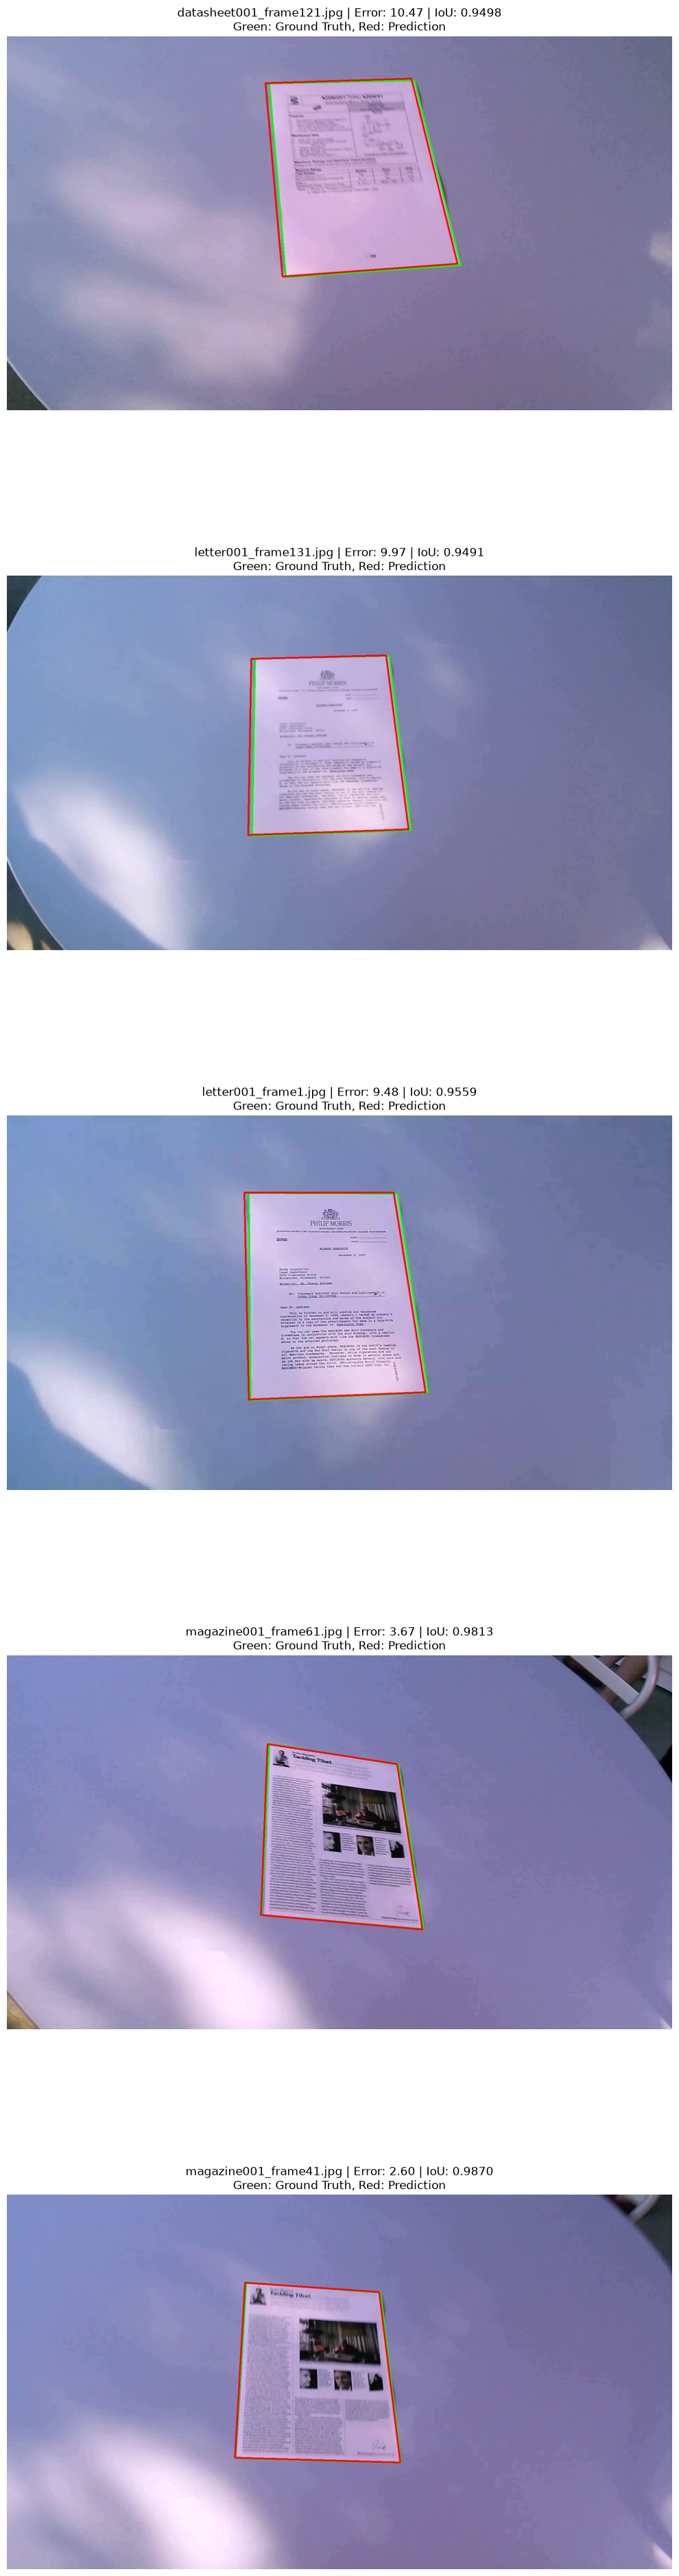

In [7]:
vis_samples = all_results[:3] + all_results[-2:]

fig, axes = plt.subplots(len(vis_samples), 1, figsize=(10, 8 * len(vis_samples)))
if len(vis_samples) == 1:
    axes = [axes]

for i, r in enumerate(vis_samples):
    vis_img = r['frame'].copy()
    vis_img = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)
    
    gt = r['gt'].astype(np.int32)
    pred = r['pred'].astype(np.int32)
    
    cv2.polylines(vis_img, [gt], True, (0, 255, 0), 4) # Green GT
    cv2.polylines(vis_img, [pred], True, (255, 0, 0), 4) # Red Pred
    
    axes[i].imshow(vis_img)
    axes[i].set_title(f"{r['filename']} | Error: {r['error']:.2f} | IoU: {r['iou']:.4f}\nGreen: Ground Truth, Red: Prediction")
    axes[i].axis('off')

plt.tight_layout()
plt.show()